In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("oddrationale/mnist-in-csv")

print("Path to dataset files:", path)

100%|██████████| 15.2M/15.2M [00:01<00:00, 9.08MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/oddrationale/mnist-in-csv/versions/2


In [ ]:
# ==============================
# Step 1: Upload MNIST CSV files
# ==============================
from google.colab import files
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split




train_df = pd.read_csv(path+"/mnist_train.csv")
test_df = pd.read_csv(path+"/mnist_test.csv")

X = train_df.iloc[:, 1:].values / 255.0  # Normalize pixels
y = train_df.iloc[:, 0].values

X_test = test_df.iloc[:, 1:].values / 255.0
y_test = test_df.iloc[:, 0].values

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

# ==============================
# Step 3: Dataset Class
# ==============================
class MNISTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = MNISTDataset(X_train, y_train)
val_dataset = MNISTDataset(X_val, y_val)
test_dataset = MNISTDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# ==============================
# Step 4: ANN Model
# ==============================
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# ==============================
# Step 5: Training Setup
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ANN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
trainacc =[]
valacc = []
trainloss = []
# ==============================
# Step 6: Training Loop
# ==============================
def train_model(model, train_loader, val_loader, epochs=10):

    for epoch in range(epochs):
        model.train()
        total_loss, correct = 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds = outputs.argmax(1)
            correct += (preds == y_batch).sum().item()

        avg_loss = total_loss / len(train_loader)
        trainloss.append(avg_loss)

        train_acc = correct / len(train_loader.dataset)
        trainacc.append(train_acc)
        # Validation
        model.eval()
        val_correct = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                preds = outputs.argmax(1)
                val_correct += (preds == y_batch).sum().item()
        val_acc = val_correct / len(val_loader.dataset)
        valacc.append(val_acc)
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Loss: {total_loss/len(train_loader):.4f}, "
              f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

train_model(model, train_loader, val_loader, epochs=30)


# ==============================
# Step 7: Test Evaluation
# ==============================
model.eval()
test_correct = 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(1)
        test_correct += (preds == y_batch).sum().item()

print(f"✅ Test Accuracy: {test_correct / len(test_loader.dataset):.4f}")





Epoch [1/30] Loss: 0.5826, Train Acc: 0.8263, Val Acc: 0.9362
Epoch [2/30] Loss: 0.2054, Train Acc: 0.9398, Val Acc: 0.9577
Epoch [3/30] Loss: 0.1456, Train Acc: 0.9569, Val Acc: 0.9648
Epoch [4/30] Loss: 0.1167, Train Acc: 0.9646, Val Acc: 0.9727
Epoch [5/30] Loss: 0.0913, Train Acc: 0.9717, Val Acc: 0.9743
Epoch [6/30] Loss: 0.0779, Train Acc: 0.9759, Val Acc: 0.9745
Epoch [7/30] Loss: 0.0653, Train Acc: 0.9797, Val Acc: 0.9762
Epoch [8/30] Loss: 0.0598, Train Acc: 0.9812, Val Acc: 0.9810
Epoch [9/30] Loss: 0.0506, Train Acc: 0.9843, Val Acc: 0.9795
Epoch [10/30] Loss: 0.0460, Train Acc: 0.9856, Val Acc: 0.9805
Epoch [11/30] Loss: 0.0413, Train Acc: 0.9862, Val Acc: 0.9802
Epoch [12/30] Loss: 0.0392, Train Acc: 0.9876, Val Acc: 0.9802
Epoch [13/30] Loss: 0.0325, Train Acc: 0.9896, Val Acc: 0.9830
Epoch [14/30] Loss: 0.0322, Train Acc: 0.9897, Val Acc: 0.9833
Epoch [15/30] Loss: 0.0284, Train Acc: 0.9900, Val Acc: 0.9845
Epoch [16/30] Loss: 0.0281, Train Acc: 0.9906, Val Acc: 0.9825
E

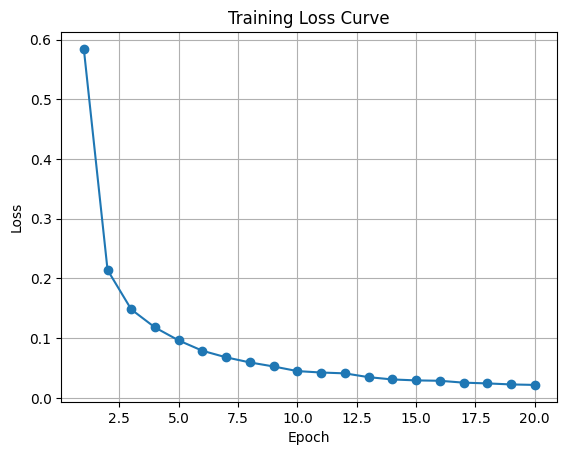

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(trainloss) + 1)

plt.plot(epochs, trainloss, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()


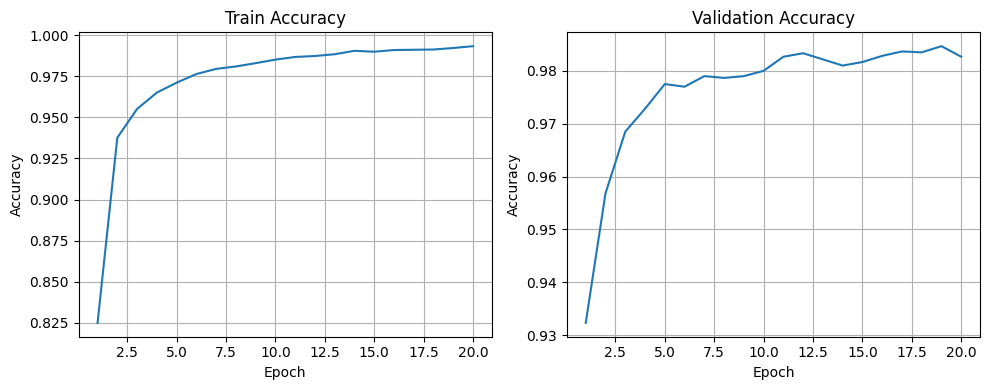

In [ ]:

import matplotlib.pyplot as plt

epochs = range(1, len(trainacc) + 1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(epochs, trainacc)
plt.title("Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(epochs, valacc)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()